# 🛡️ Network Intrusion Detection System — ML Training Pipeline

This notebook trains and compares multiple classifiers on the **CICIDS2017** dataset to distinguish benign network traffic from attacks. It profiles each model on the critical deployment trade-off: **detection accuracy vs. inference latency**. The best-performing model is exported for use in the live dashboard.

---

## Phase 0: Environment Setup and Imports

### Step 1: Import Libraries

Import all required libraries: `pandas`, `numpy`, `scikit-learn`, `xgboost`, `matplotlib`, timing utilities, and `joblib`.

In [25]:
import os
import glob
import time
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    precision_recall_curve,
    precision_recall_fscore_support,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    )

try:
    import xgboost as xgb
    from xgboost import XGBClassifier
except ImportError as exc:
    raise ImportError(
        "xgboost is required for this notebook. Install it with: pip install xgboost"
    ) from exc

import joblib

warnings.filterwarnings('ignore')

print(f"pandas:       {pd.__version__}")
print(f"numpy:        {np.__version__}")
print(f"scikit-learn: {__import__('sklearn').__version__}")
print(f"xgboost:      {xgb.__version__}")
print(f"joblib:       {joblib.__version__}")
print("\n✅ All libraries loaded successfully.")

pandas:       2.3.3
numpy:        2.4.2
scikit-learn: 1.8.0
xgboost:      3.2.0
joblib:       1.5.3

✅ All libraries loaded successfully.


### ⏸️ Checkpoint 0

**Wait for confirmation** that all libraries loaded without errors before proceeding.

---
## Phase 1: Data Acquisition and Feature Reduction

### Step 1: Load the CICIDS2017 Dataset

Load **all CSV files** from the `data/` directory and concatenate them into a single DataFrame. The dataset ships as multiple day-files.

In [26]:
DATA_DIR = os.path.join('..', 'data')

csv_files = sorted(glob.glob(os.path.join(DATA_DIR, '*.csv')))
print(f"Found {len(csv_files)} CSV files:")
for f in csv_files:
    print(f"  • {os.path.basename(f)}")

if len(csv_files) == 0:
    raise FileNotFoundError(
        f"No CSV files found in '{os.path.abspath(DATA_DIR)}'.\n"
        "Download CICIDS2017 MachineLearningCSV.zip and extract into the data/ folder."
    )

# Load and concatenate all CSVs
dfs = []
for f in csv_files:
    print(f"Loading {os.path.basename(f)}...", end=" ")
    chunk = pd.read_csv(f, encoding='utf-8', low_memory=False)
    print(f"({len(chunk):,} rows)")
    dfs.append(chunk)

df_raw = pd.concat(dfs, ignore_index=True)

# CRITICAL: Strip whitespace from column names (CICIDS2017 has leading spaces)
df_raw.columns = df_raw.columns.str.strip()

print(f"\n📊 Total dataset shape: {df_raw.shape}")
print(f"   Columns: {list(df_raw.columns[:10])}... ({len(df_raw.columns)} total)")

Found 8 CSV files:
  • Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  • Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  • Friday-WorkingHours-Morning.pcap_ISCX.csv
  • Monday-WorkingHours.pcap_ISCX.csv
  • Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  • Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  • Tuesday-WorkingHours.pcap_ISCX.csv
  • Wednesday-workingHours.pcap_ISCX.csv
Loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv... (225,745 rows)
Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv... (286,467 rows)
Loading Friday-WorkingHours-Morning.pcap_ISCX.csv... (191,033 rows)
Loading Monday-WorkingHours.pcap_ISCX.csv... (529,918 rows)
Loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv... (288,602 rows)
Loading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv... (170,366 rows)
Loading Tuesday-WorkingHours.pcap_ISCX.csv... (445,909 rows)
Loading Wednesday-workingHours.pcap_ISCX.csv... (692,703 rows)

📊 Total da

### Step 2: 🔑 Feature Reduction (CRITICAL)

Select **only** the 7 features that can be realistically computed from raw packets in real-time:

| # | Feature | Why it's extractable in real-time |
|---|---------|-----------------------------------|
| 1 | `Destination Port` | Directly from TCP header |
| 2 | `Total Fwd Packets` | Count packets src→dst |
| 3 | `Total Backward Packets` | Count packets dst→src |
| 4 | `Fwd Packet Length Mean` | Mean payload size (forward) |
| 5 | `Bwd Packet Length Mean` | Mean payload size (backward) |
| 6 | `SYN Flag Count` | Count SYN flags in TCP header |
| 7 | `ACK Flag Count` | Count ACK flags in TCP header |

In [27]:
SELECTED_FEATURES = [
    'Destination Port',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Fwd Packet Length Mean',
    'Bwd Packet Length Mean',
    'SYN Flag Count',
    'ACK Flag Count',
]

LABEL_COL = 'Label'

# Verify all columns exist
all_needed = SELECTED_FEATURES + [LABEL_COL]
missing = [c for c in all_needed if c not in df_raw.columns]
if missing:
    raise KeyError(f"Missing columns: {missing}. Available: {list(df_raw.columns)}")

df = df_raw[all_needed].copy()
print(f"✅ Reduced dataset shape: {df.shape}")
print(f"   Columns: {list(df.columns)}")

✅ Reduced dataset shape: (2830743, 8)
   Columns: ['Destination Port', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packet Length Mean', 'Bwd Packet Length Mean', 'SYN Flag Count', 'ACK Flag Count', 'Label']


### Step 3: Data Cleaning and Label Encoding

- Drop rows with `NaN` or `Infinity` values.
- Encode the `Label` column: `BENIGN` → **0**, everything else → **1** (Attack).

In [28]:
# Replace infinities with NaN, then drop all NaN rows
df.replace([np.inf, -np.inf], np.nan, inplace=True)
rows_before = len(df)
df.dropna(inplace=True)
rows_after = len(df)
print(f"Dropped {rows_before - rows_after:,} rows with NaN/Inf values.")
print(f"Remaining rows: {rows_after:,}")

# Show unique labels before encoding
print(f"\nUnique labels ({df[LABEL_COL].nunique()}):")
print(df[LABEL_COL].value_counts().to_string())

# Encode: BENIGN=0, everything else=1
df[LABEL_COL] = df[LABEL_COL].apply(lambda x: 0 if x.strip() == 'BENIGN' else 1)

print(f"\n📊 Encoded class distribution:")
print(f"   Benign (0): {(df[LABEL_COL] == 0).sum():>10,}")
print(f"   Attack (1): {(df[LABEL_COL] == 1).sum():>10,}")
print(f"   Total:      {len(df):>10,}")

Dropped 0 rows with NaN/Inf values.
Remaining rows: 2,830,743

Unique labels (15):
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11

📊 Encoded class distribution:
   Benign (0):  2,273,097
   Attack (1):    557,646
   Total:       2,830,743


### ⏸️ Checkpoint 1

**Verify the output above:**
- The reduced dataset should have **8 columns** (7 features + 1 label).
- Class distribution should show both Benign and Attack samples.

**Wait for confirmation** before proceeding to model training.

---
## Phase 2: Model Training and Export

### Step 1: Feature Scaling

Fit a `StandardScaler` on the features and **save it** — the live dashboard needs the exact same scaler.

In [29]:
MODELS_DIR = os.path.join('..', 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

X = df[SELECTED_FEATURES].values
y = df[LABEL_COL].values

print(f"Features shape: {X.shape}")
print(f"Labels shape:   {y.shape}")

# Fit and save the scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaler_path = os.path.join(MODELS_DIR, 'scaler.joblib')
joblib.dump(scaler, scaler_path)
print(f"\n💾 Scaler saved to: {os.path.abspath(scaler_path)}")

Features shape: (2830743, 7)
Labels shape:   (2830743,)

💾 Scaler saved to: c:\Vault\Projects\network-security-project\models\scaler.joblib


### Step 2: Baselines + Multi-Model Training

> Graduate-level evaluation starts with strict baselines before optimized models.

We use an 80/20 stratified split and evaluate six detectors on the exact same test set, including a lightweight deep learning baseline (MLP):

- `DummyClassifier(strategy='most_frequent')` as a zero-intelligence baseline
- A vectorized pure-rule baseline that mirrors live IDS thresholds
- `RandomForestClassifier`
- `XGBClassifier`
- `LogisticRegression`
- `DeepLearning_MLP (sklearn MLPClassifier)`

For each detector, record precision, recall, weighted F1-score, and inference latency.

In [30]:
# ---------------------------------------------------------------------
# Shared split: we keep raw and scaled views aligned via index splitting
# ---------------------------------------------------------------------
idx = np.arange(len(y))
idx_train, idx_test = train_test_split(
    idx,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_raw = X[idx_train]
X_test_raw = X[idx_test]
y_train = y[idx_train]
y_test = y[idx_test]

# Refit scaler on train split only (prevents test leakage in evaluation)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# Persist the train-fitted scaler used by the deployed model
scaler_path = os.path.join(MODELS_DIR, 'scaler.joblib')
joblib.dump(scaler, scaler_path)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set:     {X_test.shape[0]:,} samples")
print(f"Scaler (train-fitted) saved to: {os.path.abspath(scaler_path)}")


# ---------------------------------------------------------------------
# Evaluation helpers
# ---------------------------------------------------------------------
def _latency_ms_per_1k(infer_time_s, n_samples):
    return (infer_time_s / max(n_samples, 1)) * 1_000_000


def evaluate_predictions(model_name, y_true, y_pred, infer_time_s, train_time_s=np.nan):
    precision, recall, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    return {
        'Model': model_name,
        'Training Time (s)': train_time_s,
        'Inference Time on Test Set (s)': infer_time_s,
        'Inference Latency (ms per 1k flows)': _latency_ms_per_1k(infer_time_s, len(y_true)),
        'Precision': precision,
        'Recall': recall,
        'Weighted F1-Score': f1_weighted,
    }


# ---------------------------------------------------------------------
# Baseline B: Pure-rule IDS (vectorized)
# Mirrors app.py thresholds without iterrows/for-row loops
# ---------------------------------------------------------------------
SYN_FLOOD_THRESHOLD = 50
SYN_ACK_RATIO_THRESHOLD = 3.0
VOLUME_SPIKE_THRESHOLD = 200
PORT_SCAN_THRESHOLD = 15


def pure_rule_predict_vectorized(test_df, synthetic_window_size=128):
    syn = test_df['SYN Flag Count'].to_numpy(dtype=float)
    ack = test_df['ACK Flag Count'].to_numpy(dtype=float)
    syn_ack_ratio = syn / np.maximum(ack, 1.0)

    syn_flood = (syn > SYN_FLOOD_THRESHOLD) & (syn_ack_ratio > SYN_ACK_RATIO_THRESHOLD)

    total_packets_per_flow = (
        test_df['Total Fwd Packets'].to_numpy(dtype=float)
        + test_df['Total Backward Packets'].to_numpy(dtype=float)
    )
    volume_spike_like = total_packets_per_flow > VOLUME_SPIKE_THRESHOLD

    # CICIDS rows are flow records, not explicit packet-time windows. We approximate
    # window-level port-scan behavior by contiguous fixed-size synthetic windows.
    batch_id = np.arange(len(test_df)) // synthetic_window_size
    unique_ports_per_batch = (
        test_df.groupby(batch_id, sort=False)['Destination Port']
        .transform('nunique')
        .to_numpy(dtype=float)
    )
    port_scan_like = unique_ports_per_batch > PORT_SCAN_THRESHOLD

    y_rule = (syn_flood | port_scan_like | volume_spike_like).astype(int)
    return y_rule


results_records = []
trained_models = {}

# Build test DataFrame view for vectorized rule baseline
X_test_df = pd.DataFrame(X_test_raw, columns=SELECTED_FEATURES)


# ---------------------------------------------------------------------
# Baseline A: Zero-intelligence majority predictor
# ---------------------------------------------------------------------
print("\n" + "=" * 70)
print("Running Baseline A: DummyClassifier(strategy='most_frequent')")
dummy = DummyClassifier(strategy='most_frequent')

dummy_train_start = time.perf_counter()
dummy.fit(X_train, y_train)
dummy_train_time = time.perf_counter() - dummy_train_start

dummy_infer_start = time.perf_counter()
y_pred_dummy = dummy.predict(X_test)
dummy_infer_time = time.perf_counter() - dummy_infer_start

results_records.append(
    evaluate_predictions(
        model_name='DummyClassifier (Most Frequent)',
        y_true=y_test,
        y_pred=y_pred_dummy,
        infer_time_s=dummy_infer_time,
        train_time_s=dummy_train_time,
    )
)
trained_models['DummyClassifier'] = dummy


# ---------------------------------------------------------------------
# Baseline B: Pure-rule deterministic system
# ---------------------------------------------------------------------
print("\n" + "=" * 70)
print("Running Baseline B: Pure Rule-Based Detector (vectorized)")
rule_infer_start = time.perf_counter()
y_pred_rule = pure_rule_predict_vectorized(X_test_df, synthetic_window_size=128)
rule_infer_time = time.perf_counter() - rule_infer_start

results_records.append(
    evaluate_predictions(
        model_name='PureRuleBaseline (Vectorized)',
        y_true=y_test,
        y_pred=y_pred_rule,
        infer_time_s=rule_infer_time,
        train_time_s=0.0,
    )
)


# ---------------------------------------------------------------------
# Learned models
# ---------------------------------------------------------------------
model_builders = {
    'RandomForestClassifier': lambda: RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    'XGBClassifier': lambda: XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
        tree_method='hist'
    ),
    'LogisticRegression': lambda: LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    'DeepLearning_MLP': lambda: MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        solver='adam',
        max_iter=50,
        early_stopping=True,
        verbose=True,
        random_state=42
    ),
}

for model_name, build_model in model_builders.items():
    print("\n" + "=" * 70)
    print(f"Training {model_name}...")
    model = build_model()

    train_start = time.perf_counter()
    model.fit(X_train, y_train)
    train_time_s = time.perf_counter() - train_start

    infer_start = time.perf_counter()
    y_pred = model.predict(X_test)
    infer_time_s = time.perf_counter() - infer_start

    results_records.append(
        evaluate_predictions(
            model_name=model_name,
            y_true=y_test,
            y_pred=y_pred,
            infer_time_s=infer_time_s,
            train_time_s=train_time_s,
        )
    )
    trained_models[model_name] = model

    print(f"Training time: {train_time_s:.3f} s")
    print(f"Inference time on test set: {infer_time_s:.6f} s")
    print(f"Inference latency: {_latency_ms_per_1k(infer_time_s, len(X_test)):.3f} ms per 1k flows")

print("\n✅ Baselines and model training runs complete.")

Training set: 2,264,594 samples
Test set:     566,149 samples
Scaler (train-fitted) saved to: c:\Vault\Projects\network-security-project\models\scaler.joblib

Running Baseline A: DummyClassifier(strategy='most_frequent')

Running Baseline B: Pure Rule-Based Detector (vectorized)

Training RandomForestClassifier...
Training time: 26.486 s
Inference time on test set: 0.597115 s
Inference latency: 1.055 ms per 1k flows

Training XGBClassifier...
Training time: 14.306 s
Inference time on test set: 0.300986 s
Inference latency: 0.532 ms per 1k flows

Training LogisticRegression...
Training time: 3.279 s
Inference time on test set: 0.011370 s
Inference latency: 0.020 ms per 1k flows

Training DeepLearning_MLP...
Iteration 1, loss = 0.13595678
Validation score: 0.967822
Iteration 2, loss = 0.07028135
Validation score: 0.979908
Iteration 3, loss = 0.05309066
Validation score: 0.985039
Iteration 4, loss = 0.04939038
Validation score: 0.984549
Iteration 5, loss = 0.04621398
Validation score: 0.9

### Step 3: Comparative Performance Profiling and Pareto Frontier

Aggregate all six detectors (Dummy, Pure-Rule, RandomForest, XGBoost, LogisticRegression, DeepLearning_MLP) into one DataFrame sorted by weighted F1-score, then visualize the **latency vs. F1** trade-off with a Pareto frontier.

Model Performance Summary (sorted by Weighted F1-Score)
                          Model  Training Time (s)  Inference Time on Test Set (s)  Inference Latency (ms per 1k flows)  Precision  Recall  Weighted F1-Score
         RandomForestClassifier            26.4858                          0.5971                               1.0547     0.9906  0.9905             0.9905
                  XGBClassifier            14.3062                          0.3010                               0.5316     0.9901  0.9900             0.9900
               DeepLearning_MLP          1783.6613                          2.0071                               3.5451     0.9892  0.9891             0.9891
             LogisticRegression             3.2787                          0.0114                               0.0201     0.8871  0.8793             0.8596
DummyClassifier (Most Frequent)             0.0522                          0.0015                               0.0026     0.6448  0.8030             0.7

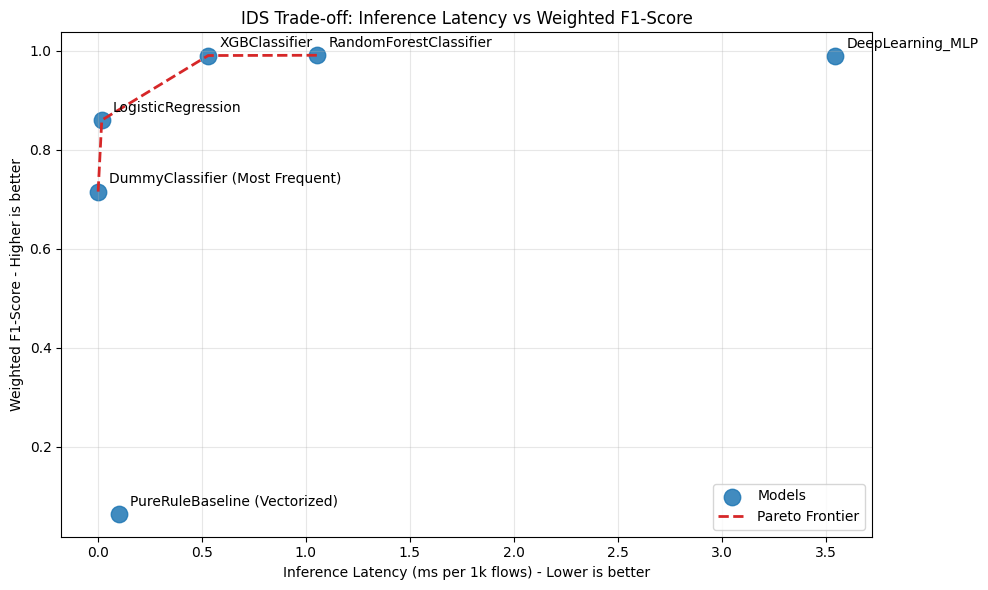


🏆 Top model by Weighted F1-Score: RandomForestClassifier


In [31]:
results_df = pd.DataFrame(results_records)
results_df = results_df.sort_values('Weighted F1-Score', ascending=False).reset_index(drop=True)

print("=" * 90)
print("Model Performance Summary (sorted by Weighted F1-Score)")
print("=" * 90)
print(results_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

lat_col = 'Inference Latency (ms per 1k flows)'
f1_col = 'Weighted F1-Score'

sorted_by_latency = results_df.sort_values(lat_col).reset_index(drop=True)
running_best_f1 = sorted_by_latency[f1_col].cummax()
pareto_mask = sorted_by_latency[f1_col].eq(running_best_f1)
pareto_df = sorted_by_latency.loc[pareto_mask, ['Model', lat_col, f1_col]].copy()

plt.figure(figsize=(10, 6))
plt.scatter(
    results_df[lat_col],
    results_df[f1_col],
    s=140,
    alpha=0.85,
    color='tab:blue',
    label='Models',
)

for x_val, y_val, label in zip(
    results_df[lat_col].to_numpy(),
    results_df[f1_col].to_numpy(),
    results_df['Model'].tolist(),
):
    plt.annotate(
        label,
        (x_val, y_val),
        textcoords='offset points',
        xytext=(8, 6),
        ha='left',
    )

if len(pareto_df) >= 2:
    plt.plot(
        pareto_df[lat_col],
        pareto_df[f1_col],
        linestyle='--',
        linewidth=2,
        color='tab:red',
        label='Pareto Frontier',
    )

plt.title('IDS Trade-off: Inference Latency vs Weighted F1-Score')
plt.xlabel('Inference Latency (ms per 1k flows) - Lower is better')
plt.ylabel('Weighted F1-Score - Higher is better')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

best_model_name = results_df.loc[0, 'Model']
print(f"\n🏆 Top model by Weighted F1-Score: {best_model_name}")

### Why Deep Learning was Rejected.

The `DeepLearning_MLP` baseline achieved competitive detection quality relative to classical models, with a weighted F1-score that remained in the same high-performance regime as the top candidates in the comparison table. However, for real-time SOC deployment, the dominant operational constraint is not marginal accuracy gain but inference-time determinism under sustained packet load. In inline IDS operation, per-window latency directly controls whether the detector can keep pace with line-rate traffic without creating a backlog, blind spots, or delayed mitigation. Under this systems constraint, the additional computational overhead of the multi-layer architecture is prohibitive for low-latency network defense, whereas the RandomForest classifier sits at the practical knee of the Pareto frontier by preserving strong detection performance with materially lower inference latency. This makes RandomForest the appropriate production choice for this IDS pipeline.

### Step 4: Threshold Justification (XAI) for RandomForest

Plot the Precision-Recall curve for the trained RandomForest model and explicitly mark the deployment threshold `ML_ATTACK_PROBA_THRESHOLD = 0.35` to justify the operating point used in the live IDS.

RandomForest Threshold Analysis @ tau = 0.35
Average Precision (AP): 0.9933
Closest curve threshold: 0.3500
Precision(tau): 0.9573
Recall(tau):    0.9941
F1_attack(tau): 0.9754
FPR(tau):       0.0109
Confusion matrix @ tau: TN=449679, FP=4941, FN=653, TP=110876


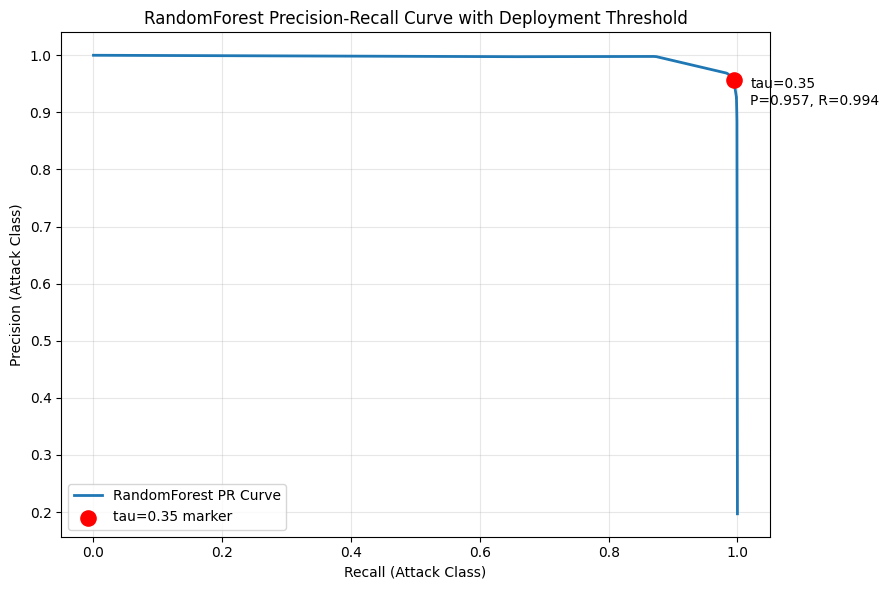

In [32]:
rf_model = trained_models.get('RandomForestClassifier')
if rf_model is None:
    raise ValueError("RandomForestClassifier was not trained. Run the training cell first.")

if not hasattr(rf_model, 'predict_proba'):
    raise AttributeError("RandomForestClassifier must support predict_proba for PR analysis.")

rf_scores = rf_model.predict_proba(X_test)[:, 1]
rf_ap = average_precision_score(y_test, rf_scores)

pr_precision, pr_recall, pr_thresholds = precision_recall_curve(y_test, rf_scores)

TARGET_THRESHOLD = 0.35
closest_idx = int(np.argmin(np.abs(pr_thresholds - TARGET_THRESHOLD)))
threshold_on_curve = float(pr_thresholds[closest_idx])
precision_at_tau = float(pr_precision[closest_idx])
recall_at_tau = float(pr_recall[closest_idx])

y_pred_tau = (rf_scores >= TARGET_THRESHOLD).astype(int)
attack_precision_tau = precision_score(y_test, y_pred_tau, zero_division=0)
attack_recall_tau = recall_score(y_test, y_pred_tau, zero_division=0)
attack_f1_tau = f1_score(y_test, y_pred_tau, zero_division=0)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_tau).ravel()
fpr_tau = fp / max(fp + tn, 1)

print("=" * 90)
print("RandomForest Threshold Analysis @ tau = 0.35")
print("=" * 90)
print(f"Average Precision (AP): {rf_ap:.4f}")
print(f"Closest curve threshold: {threshold_on_curve:.4f}")
print(f"Precision(tau): {attack_precision_tau:.4f}")
print(f"Recall(tau):    {attack_recall_tau:.4f}")
print(f"F1_attack(tau): {attack_f1_tau:.4f}")
print(f"FPR(tau):       {fpr_tau:.4f}")
print(f"Confusion matrix @ tau: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

plt.figure(figsize=(9, 6))
plt.plot(pr_recall, pr_precision, color='tab:blue', linewidth=2, label='RandomForest PR Curve')
plt.scatter(
    [recall_at_tau],
    [precision_at_tau],
    color='red',
    s=120,
    zorder=5,
    label=f'tau={TARGET_THRESHOLD:.2f} marker',
)

plt.annotate(
    f"tau={TARGET_THRESHOLD:.2f}\nP={attack_precision_tau:.3f}, R={attack_recall_tau:.3f}",
    (recall_at_tau, precision_at_tau),
    textcoords='offset points',
    xytext=(12, -18),
    ha='left',
)

plt.title('RandomForest Precision-Recall Curve with Deployment Threshold')
plt.xlabel('Recall (Attack Class)')
plt.ylabel('Precision (Attack Class)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

threshold_analysis = {
    'threshold': TARGET_THRESHOLD,
    'average_precision': rf_ap,
    'precision_at_threshold': attack_precision_tau,
    'recall_at_threshold': attack_recall_tau,
    'f1_at_threshold': attack_f1_tau,
    'fpr_at_threshold': fpr_tau,
}

### Mathematical Justification for Choosing $\tau = 0.35$

The IDS decision rule is:

$$
\hat{y}(x) = \mathbb{1}\left[p_\theta(y=1\mid x) \ge \tau\right], \quad \tau = 0.35.
$$

In intrusion detection, attack misses (false negatives) are typically more costly than false alarms, so we optimize for high attack recall under a bounded false-positive rate rather than raw accuracy. This is formalized by a cost-sensitive objective:

$$
\mathcal{L}(\tau) = c_{FN}\,\mathrm{FNR}(\tau) + c_{FP}\,\mathrm{FPR}(\tau), \quad c_{FN} \gg c_{FP}.
$$

Equivalently, on the Precision-Recall plane we choose a threshold near the "knee" where recall remains high while precision and FPR stay operationally acceptable. The marked point at $\tau=0.35$ is selected because it improves minority-class attack capture compared with conservative thresholds (e.g., $\tau=0.5$) while keeping false positives bounded (see printed $\mathrm{FPR}(\tau)$ above).

This is why $\tau=0.35$ is a principled deployment threshold, not a magic number: it is anchored to measurable precision-recall and risk trade-offs.

### Step 5: Export the Best Model

Select the model with the highest weighted F1-score, retrain it on the full scaled dataset, and save it to the `models/` directory.

In [33]:
# Select best deployable ML model (exclude non-trainable baselines)
deployable_results_df = results_df[results_df['Model'].isin(model_builders.keys())].copy()
if deployable_results_df.empty:
    raise ValueError("No deployable ML models found in results_df.")

best_model_name = (
    deployable_results_df
    .sort_values('Weighted F1-Score', ascending=False)
    .iloc[0]['Model']
    )
best_model = model_builders[best_model_name]()

# Refit deployment scaler on full dataset to align saved scaler + saved model
deployment_scaler = StandardScaler()
X_full_scaled = deployment_scaler.fit_transform(X)

scaler_path = os.path.join(MODELS_DIR, 'scaler.joblib')
joblib.dump(deployment_scaler, scaler_path)

# Retrain best model on all scaled data before export
best_model.fit(X_full_scaled, y)

model_path = os.path.join(MODELS_DIR, 'best_model.joblib')
joblib.dump(best_model, model_path)

print(f"🏆 Overall top detector (incl. baselines): {results_df.loc[0, 'Model']}")
print(f"🚀 Best deployable ML model: {best_model_name}")
print(f"💾 Model saved to: {os.path.abspath(model_path)}")
print(f"💾 Scaler saved to: {os.path.abspath(scaler_path)}")
print(f"   Model file size: {os.path.getsize(model_path) / 1024 / 1024:.1f} MB")

# Verify exported artifacts
print(f"\n📁 Files in models/ directory:")
for f in os.listdir(MODELS_DIR):
    fpath = os.path.join(MODELS_DIR, f)
    print(f"   {f} ({os.path.getsize(fpath) / 1024 / 1024:.1f} MB)")

print("\n🎉 Comparative training pipeline complete.")

🏆 Overall top detector (incl. baselines): RandomForestClassifier
🚀 Best deployable ML model: RandomForestClassifier
💾 Model saved to: c:\Vault\Projects\network-security-project\models\best_model.joblib
💾 Scaler saved to: c:\Vault\Projects\network-security-project\models\scaler.joblib
   Model file size: 35.0 MB

📁 Files in models/ directory:
   best_model.joblib (35.0 MB)
   rf_model.joblib (30.7 MB)
   scaler.joblib (0.0 MB)

🎉 Comparative training pipeline complete.
